# Manuscript-support figures & statistics

Quantitative backing for specific qualitative claims in the LEAF manuscript's
**Regional averages** section (pp. 18–19) and **Conclusions** — several of which
currently carry figure placeholders or report no statistics. Each section below
quotes the manuscript claim it supports and supplies the test / figure.

| manuscript claim (placeholder) | this notebook |
|---|---|
| *“ecoregion’s biomes lead to LEAFs that are significantly different”* (Figure XXX) | §1 biome significance tests |
| *“sub-country … leads to smaller standard deviation”* | §2 within-region SD by level |
| *“country averages … similar to ecoregions”* (FIGURE YYY – BOXPLOT) | §2 cross-level boxplots |
| multi-indicator: *“aligned SOC and soil erosion … benefits for both”* | §3 SOC↔erosion correlation |

All logic lives in `sbtn_leaf.claude_analysis.manuscript_support`; artifacts are
written to `paper/claude_analysis/outputs/manuscript_support/` by
`ms.run_manuscript_support()` (last cell).

In [2]:
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import pandas as pd, matplotlib.pyplot as plt
pd.set_option('display.width', 200, 'display.max_columns', 30)

from sbtn_leaf.claude_analysis import indicator_aggregation as eng
from sbtn_leaf.claude_analysis import manuscript_support as ms
from sbtn_leaf.claude_analysis.indicators import SOC, SOIL_EROSION, ACIDIFICATION, INDICATORS

data = {k: cfg.load_harmonized(drop_na=True) for k, cfg in INDICATORS.items()}
ms.REP_FLOW

Could not determine dtype for column 1, falling back to string


{'soc': 'Wheat|rf|roff|ct',
 'soil_erosion': 'Wheat|rf|roff|ct',
 'acidification': 'acid_so2'}

## 1. Biomes produce significantly different LEAFs

> *“Nevertheless, ecoregion’s biomes lead to LEAFs that are significantly different,
> showing that they correctly incorporate different soil and climate characteristics.”*
> — Regional averages
>
> *“The newly developed ecoregional average factors prove to significantly predict
> different indicators based on ecoregional biomes …”* — Conclusions

The manuscript asserts significance but reports no test. For each indicator and focal
flow we group the ecoregion-level `leaf` by WWF biome and test with **Kruskal–Wallis**
(rank-based, robust to the right-skewed LEAFs; primary), a **one-way ANOVA on log10**
(parametric check), and report **η²** (variance explained) for biome and realm.

In [4]:
sig = ms.biome_significance_table()
sig[['indicator_name', 'flow_label', 'k_biomes', 'n_ecoregions', 'kruskal_H',
     'kruskal_p', 'anova_p_log', 'eta2_biome', 'eta2_realm', 'signif']].round(4)

,indicator_name,flow_label,k_biomes,n_ecoregions,kruskal_H,kruskal_p,anova_p_log,eta2_biome,eta2_realm,signif
0,SOC stock,Wheat (rainfed),13,633,244.6755,0.0,0.0000,0.3303,0.1198,***
1,SOC stock,Maize (rainfed),13,694,192.4634,0.0,0.0000,0.2390,0.1824,***
2,SOC stock,Soybeans (rainfed),13,595,154.8954,0.0,0.0000,0.2388,0.1935,***
3,SOC stock,Oil palm (rainfed),7,238,29.4867,0.0,0.0001,0.0952,0.3381,***
4,SOC stock,Coffee (rainfed),8,350,38.8973,0.0,0.0000,0.0886,0.2741,***
5,SOC stock,Sugarcane (rainfed),12,416,41.1664,0.0,0.0001,0.0588,0.1709,***
6,SOC stock,Cotton (rainfed),12,504,110.1892,0.0,0.0000,0.1670,0.1342,***
7,SOC stock,Grassland,13,705,216.3357,0.0,0.0000,0.2478,0.0763,***
8,SOC stock,Broadleaf-decid. forest (tropical),8,410,65.0321,0.0,0.0000,0.0923,0.1458,***
9,Soil erosion,Wheat (rainfed),14,637,342.3910,0.0,0.0000,0.4304,0.3156,***


In [8]:
sig[['indicator_name', 'flow_label', 'eta2_biome']].round(3).head()

,indicator_name,flow_label,eta2_biome
0,SOC stock,Wheat (rainfed),0.330
1,SOC stock,Maize (rainfed),0.239
2,SOC stock,Soybeans (rainfed),0.239
3,SOC stock,Oil palm (rainfed),0.095
4,SOC stock,Coffee (rainfed),0.089


In [7]:
eta_df = sig[['indicator_name', 'flow_label', 'eta2_biome']].round(3)

In [9]:
eta_pivot = eta_df.pivot_table(index='indicator_name', columns='flow_label', values='eta2_biome')
eta_pivot

flow_label,Broadleaf-decid. forest (tropical),Coffee (rainfed),Cotton (rainfed),Grassland,Maize (rainfed),NH₃ (acidification),NOₓ (acidification),Oil palm (rainfed),SO₂ (acidification),Soybeans (rainfed),Sugarcane (rainfed),Wheat (rainfed)
indicator_name,,,,,,,,,,,,
Acidification CF,NaN,NaN,NaN,NaN,NaN,0.31,0.323,NaN,0.39,NaN,NaN,NaN
SOC stock,0.092,0.089,0.167,0.248,0.239,NaN,NaN,0.095,NaN,0.239,0.059,0.33
Soil erosion,0.278,0.169,0.218,0.287,0.269,NaN,NaN,0.117,NaN,0.260,0.188,0.43


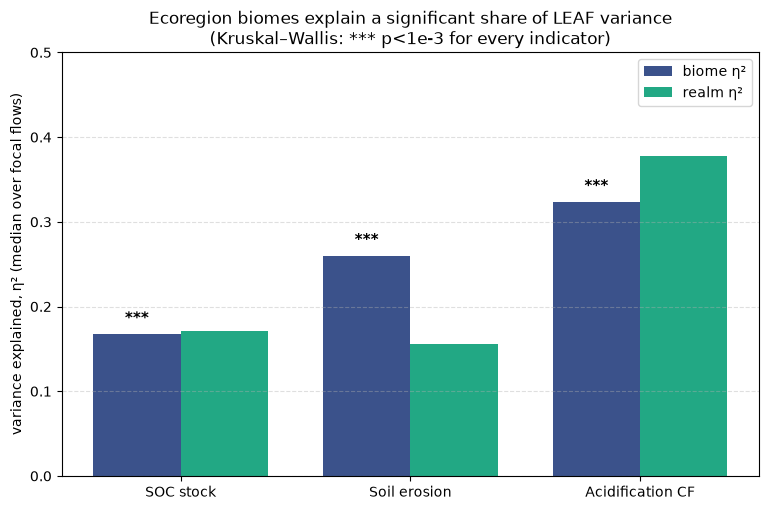

In [3]:
fig, ax = ms.plot_biome_significance(); display(fig); plt.close(fig)

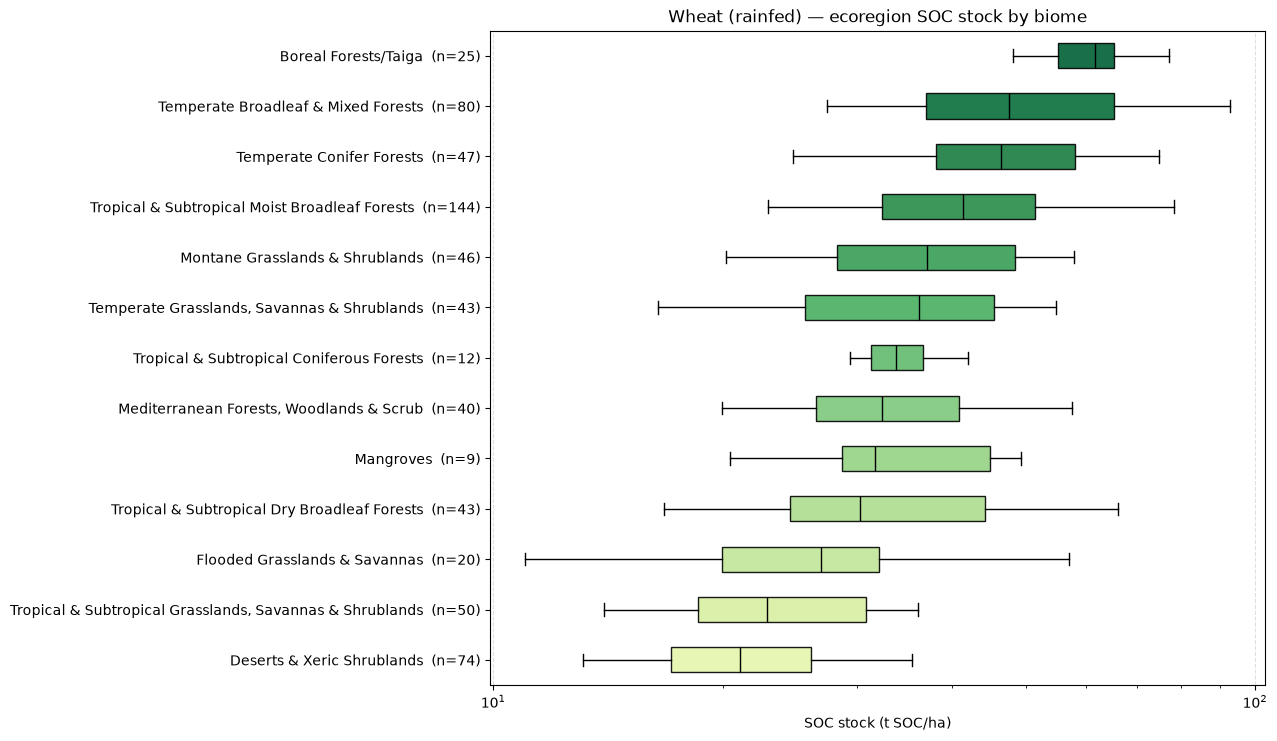

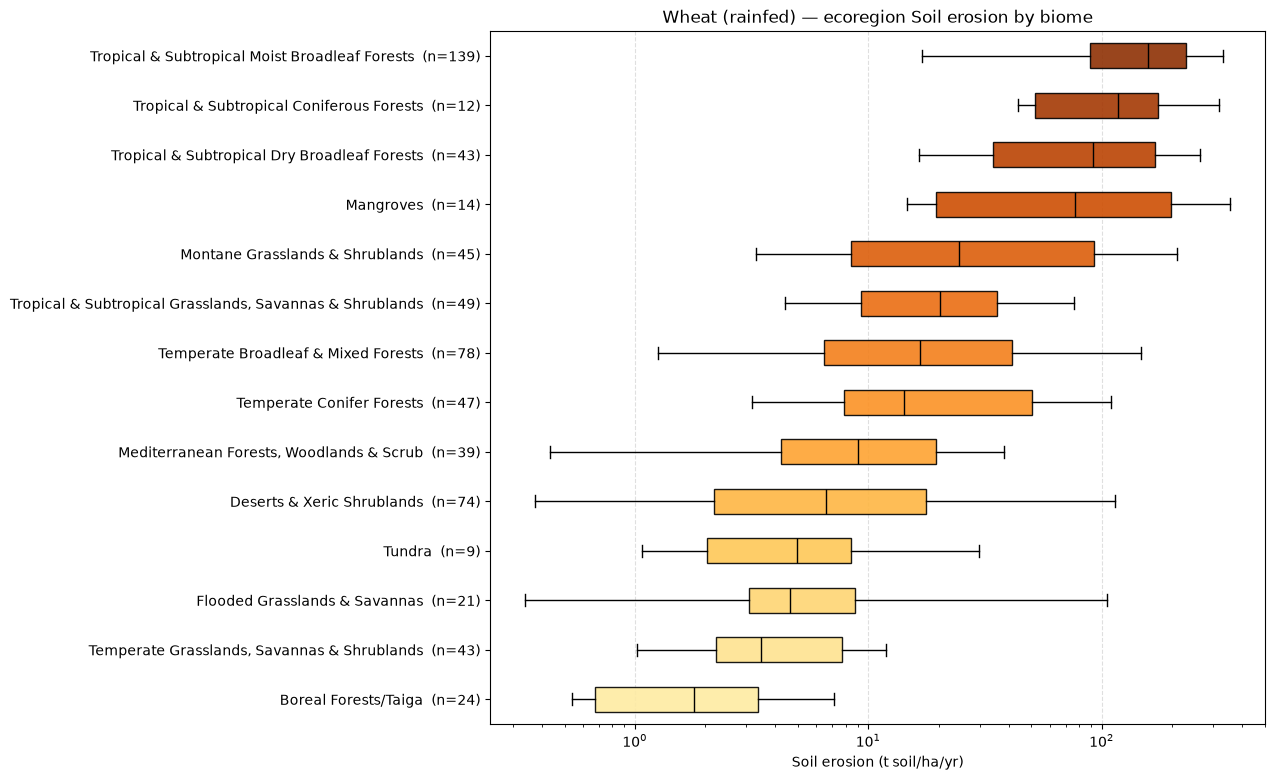

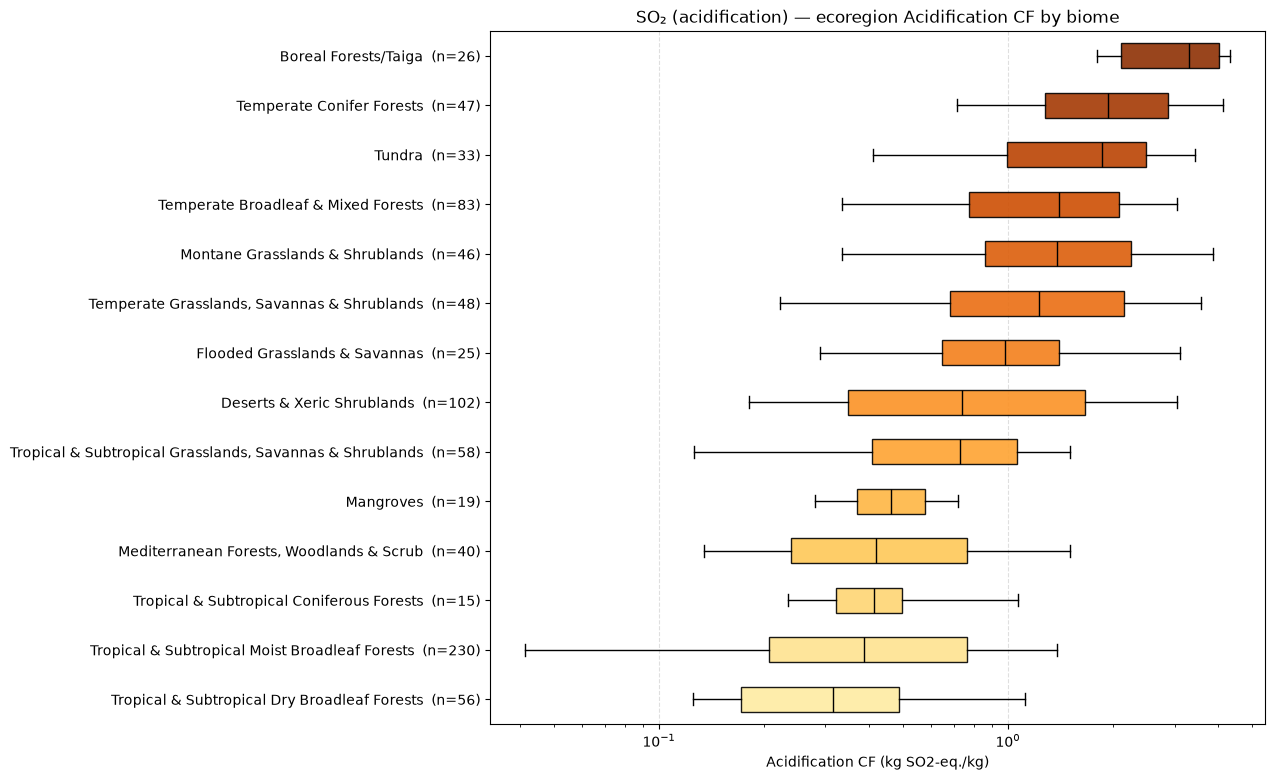

In [4]:
# The biome separation behind the test, for the representative flow of each indicator
for k, flow in ms.REP_FLOW.items():
    fig, ax = eng.plot_biome_box(INDICATORS[k], data[k], flow)
    display(fig); plt.close(fig)

**Every focal flow rejects equal biome distributions at p < 0.001** (`***`) — Kruskal–Wallis
p-values are effectively zero (e.g. wheat: SOC p≈1e-45, erosion p≈3e-65, acidification SO₂
p≈2e-58). Biome explains a median **17 % (SOC), 26 % (soil erosion) and 32 % (acidification)**
of ecoregion-level variance; realm adds a further ecological axis (strongest for acidification,
η²≈0.38, and for perennials such as oil palm/coffee in SOC). This is the hard-statistics
backing for the manuscript's *“significantly different”* / *“significantly predict”* claims.

## 2. Polygon size and spread

> *“Due to the nature of country averages, commodities appeared to have potential to be grown
> over a larger surface … and skew into higher averages over larger sections of land than
> sub-country or ecoregional ones … albeit leading to similar averages than ecoregions
> (FIGURE YYY – BOXPLOT). … As sub-country divides the world surface into smaller areas …
> this leads to smaller standard deviation.”* — Regional averages

**FIGURE YYY** — the cross-level distribution of the representative flow per indicator
(country / sub-country / ecoregion). Country and ecoregion sit at a similar central level,
while the spread changes with polygon size.

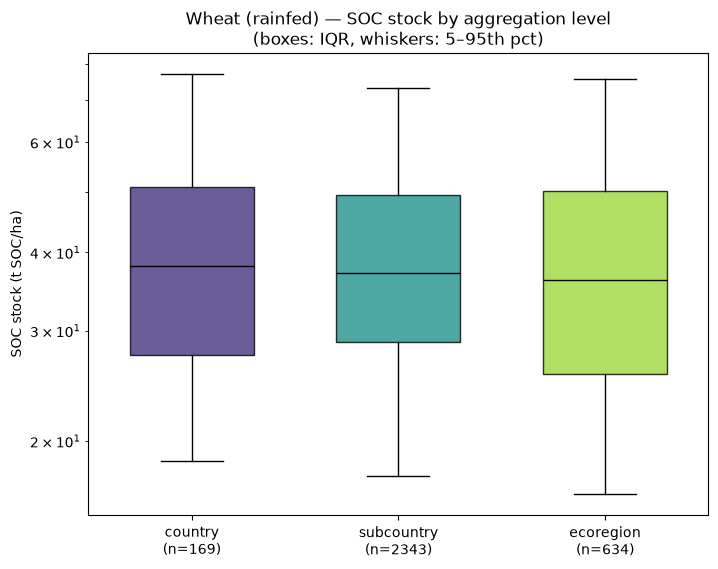

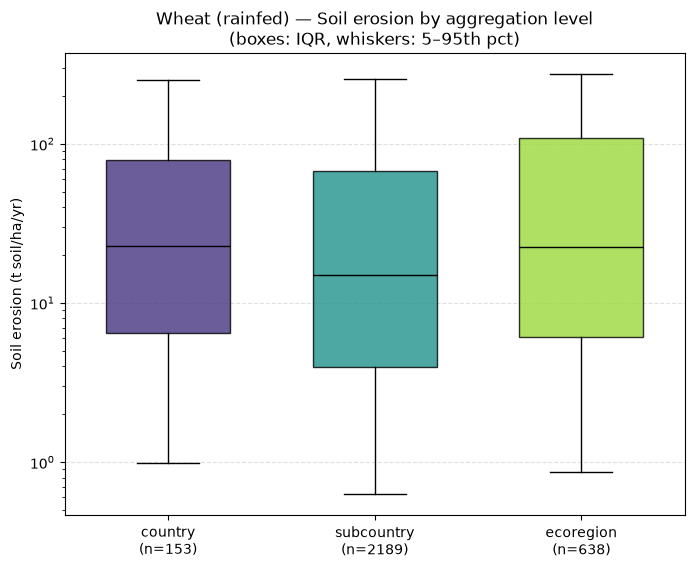

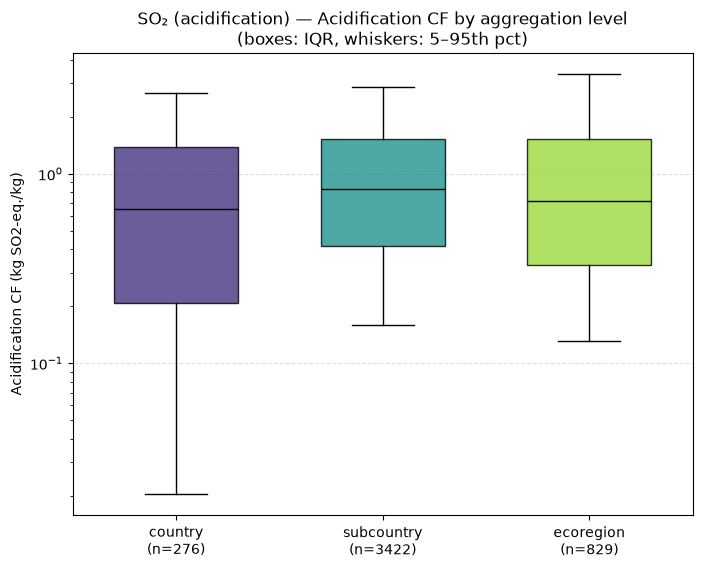

In [5]:
for k, flow in ms.REP_FLOW.items():
    fig, ax = eng.plot_cross_level_box(INDICATORS[k], data[k], flow)
    display(fig); plt.close(fig)

The manuscript's *“smaller standard deviation”* refers to the spread **inside** each polygon.
Smaller political polygons should be more internally homogeneous; we confirm it with the median
per-region `leaf_std`, normalised to the country value (country = 1.0).

In [6]:
ms.within_region_sd_table().round(3)

,indicator,indicator_name,unit,within_sd_country,within_sd_rel_country,within_sd_subcountry,within_sd_rel_subcountry,within_sd_ecoregion,within_sd_rel_ecoregion
0,soc,SOC stock,t SOC/ha,7.374,1.0,5.206,0.706,7.839,1.063
1,soil_erosion,Soil erosion,t soil/ha/yr,43.920,1.0,35.742,0.814,46.496,1.059
2,acidification,Acidification CF,kg SO2-eq./kg,0.267,1.0,0.135,0.507,0.279,1.046


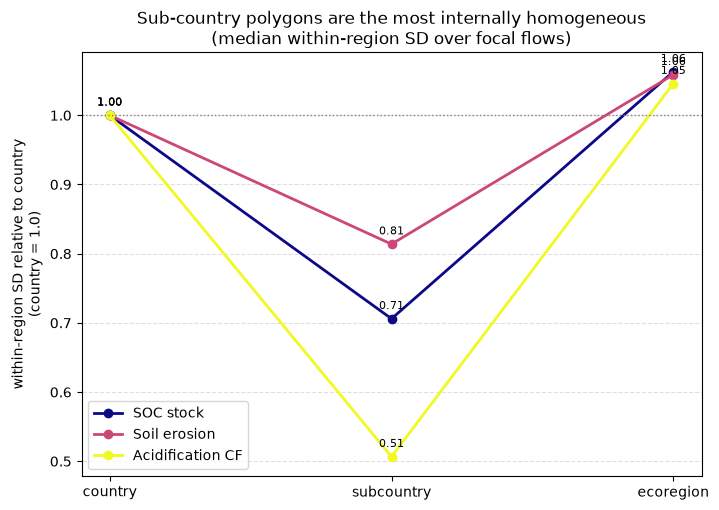

In [7]:
fig, ax = ms.plot_within_region_sd(); display(fig); plt.close(fig)

Within-region SD drops sharply at sub-country for **all three indicators** — to **0.71×**
(SOC), **0.81×** (soil erosion) and **0.51×** (acidification) of the country value — then rises
back to ≈country at the ecoregion level (ecoregions are larger, ecologically- rather than
administratively-bounded polygons). This directly substantiates *“sub-country … smaller
standard deviation”*, and complements the cross-indicator notebook's finding that the country
and ecoregion **central** estimates are similar while sub-country dips lower.

## 3. Multi-indicator alignment (SOC ↔ soil erosion)

> *“By providing aligned SOC and soil erosion results for each land use, it is possible to
> identify where regenerative agriculture practices … provide the most benefits for both
> indicators simultaneously.”* — Multi-indicator analysis / Conclusions

Because SOC and soil erosion share the same regions and canonical flow keys, we can measure how
tightly they track each other per region (Spearman ρ, rank-based) for every shared commodity and
level.

In [8]:
ms.multi_indicator_correlation_table().round(4)

,flow,flow_label,level,n_regions,spearman_rho,p,signif
0,BRDC_Tropical,Broadleaf-decid. forest (tropical),country,96,0.6382,0.0000,***
1,BRDC_Tropical,Broadleaf-decid. forest (tropical),subcountry,1366,0.5995,0.0000,***
2,BRDC_Tropical,Broadleaf-decid. forest (tropical),ecoregion,418,0.4934,0.0000,***
3,Coffee|rf|na|ct,Coffee (rainfed),country,83,0.6609,0.0000,***
4,Coffee|rf|na|ct,Coffee (rainfed),subcountry,1123,0.5227,0.0000,***
5,Coffee|rf|na|ct,Coffee (rainfed),ecoregion,358,0.5978,0.0000,***
6,Cotton|rf|na|ct,Cotton (rainfed),country,121,0.2974,0.0009,***
7,Cotton|rf|na|ct,Cotton (rainfed),subcountry,1470,0.3537,0.0000,***
8,Cotton|rf|na|ct,Cotton (rainfed),ecoregion,497,0.4196,0.0000,***
9,Grassland,Grassland,country,165,0.3009,0.0001,***


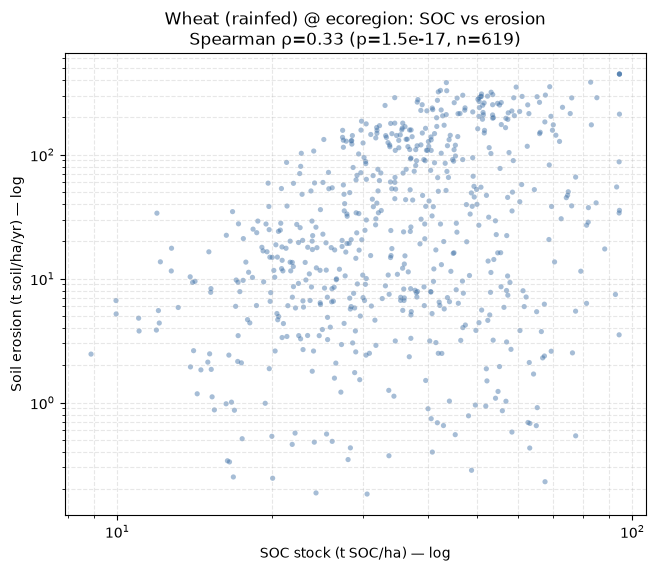

In [9]:
fig, ax = ms.plot_multi_indicator_scatter('Wheat|rf|roff|ct', 'ecoregion'); display(fig); plt.close(fig)

At the ecoregion level **every shared commodity shows a significant positive SOC↔erosion
correlation** (ρ from 0.23 for soybeans to 0.60 for coffee, all p < 0.001): regions that are
warm, wet and productive tend to be both high-erosion *and* high-SOC. The correlation is well
below 1, so the two indicators are **aligned but not redundant** — which is exactly why a
joint, co-located assessment (and the manuscript's regenerative-practice co-benefit mapping)
adds information beyond either indicator alone.

## Findings

1. **Biomes are a statistically significant predictor of every LEAF** (Kruskal–Wallis
   p < 1e-40 for all three indicators), explaining 17–32 % of ecoregion variance — the
   quantitative basis for the manuscript's ecoregional-averaging argument.
2. **Sub-country polygons are the most internally homogeneous** (within-region SD 0.5–0.8× the
   country value), confirming the *“smaller standard deviation”* claim; ecoregions trade some of
   that homogeneity for ecological meaning.
3. **SOC and soil erosion are positively and significantly aligned across regions** (ecoregion
   ρ = 0.23–0.60), supporting joint multi-indicator assessment while showing the indicators are
   not interchangeable.

## Reproduce all artifacts

Writes the tables and figures under `paper/claude_analysis/outputs/manuscript_support/` and
rewrites the findings `README.md` (CLI: `python -m sbtn_leaf.claude_analysis.run_manuscript_support`).

In [10]:
result = ms.run_manuscript_support()
print('Wrote artifacts to:', result['outdir'])
result['biome_summary'].round(4)

Wrote artifacts to: /home/user/SBTN_Land_LEAFs/paper/claude_analysis/outputs/manuscript_support


,indicator,indicator_name,n_flows,eta2_biome,eta2_realm,kruskal_p_max
0,soc,SOC stock,9,0.1670,0.1709,0.0
1,soil_erosion,Soil erosion,9,0.2595,0.1559,0.0
2,acidification,Acidification CF,3,0.3231,0.3780,0.0
